In [1]:
!pip install torch torchvision
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import timm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


In [18]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

classes = trainset.classes

In [33]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [20]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, emb_size=256, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        self.pos_embed = nn.Parameter(torch.randn((img_size // patch_size) ** 2 + 1, emb_size))

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embed
        return x

class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_size, num_heads, ff_hidden_mult=4, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(emb_size)
        self.mha = nn.MultiheadAttention(emb_size, num_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(emb_size)
        self.ff = nn.Sequential(
            nn.Linear(emb_size, ff_hidden_mult * emb_size),
            nn.GELU(),
            nn.Linear(ff_hidden_mult * emb_size, emb_size)
        )

    def forward(self, x):
        x = x + self.mha(self.ln1(x), self.ln1(x), self.ln1(x))[0]
        x = x + self.ff(self.ln2(x))
        return x

class ViT(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, emb_size=256, img_size=32, num_classes=10, depth=6, heads=8):
        super().__init__()
        self.patch_embed = PatchEmbedding(in_channels, patch_size, emb_size, img_size)
        self.encoder = nn.Sequential(*[TransformerEncoderBlock(emb_size, heads) for _ in range(depth)])
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, num_classes)
        )

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.encoder(x)
        x = x[:, 0]
        return self.mlp_head(x)

In [21]:
def train(model, criterion, optimizer, train_loader, val_loader, epochs=10, patience=3):
    model.to(device)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    train_loss, val_loss, train_acc, val_acc = [], [], [], []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        acc = 100 * correct / total
        train_loss.append(running_loss / len(train_loader))
        train_acc.append(acc)

        # Validation
        model.eval()
        correct, total = 0, 0
        val_running_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        acc = 100 * correct / total
        val_loss_epoch = val_running_loss / len(val_loader)
        val_loss.append(val_loss_epoch)
        val_acc.append(acc)
        scheduler.step()

        print(f"Epoch {epoch+1}: Train Acc={train_acc[-1]:.2f}%, Val Acc={val_acc[-1]:.2f}%, Val Loss={val_loss_epoch:.4f}")

        # Early stopping check
        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    return train_loss, val_loss, train_acc, val_acc

In [22]:
def get_pretrained_vit():
    model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=10)
    return model

Inference & Evaluation


In [23]:
# cnn_model = CNN()
# vit_model = ViT()
# pretrained_vit = PretrainedViT()

# train(cnn_model, trainloader, testloader, epochs=10)
# train(vit_model, trainloader, testloader, epochs=10)
# train(pretrained_vit, trainloader, testloader, epochs=10)

In [35]:
def evaluate(model, test_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

Training CNN...
Epoch 1: Train Acc=36.95%, Val Acc=53.04%, Val Loss=1.3090
Epoch 2: Train Acc=46.92%, Val Acc=56.59%, Val Loss=1.1893
Epoch 3: Train Acc=51.12%, Val Acc=59.27%, Val Loss=1.1493
Epoch 4: Train Acc=53.32%, Val Acc=63.56%, Val Loss=1.0170
Epoch 5: Train Acc=55.36%, Val Acc=62.52%, Val Loss=1.0473
Epoch 6: Train Acc=58.30%, Val Acc=67.47%, Val Loss=0.9398
Epoch 7: Train Acc=59.33%, Val Acc=67.66%, Val Loss=0.8978
Epoch 8: Train Acc=59.90%, Val Acc=68.32%, Val Loss=0.9070
Epoch 9: Train Acc=60.56%, Val Acc=69.05%, Val Loss=0.8735
Epoch 10: Train Acc=61.11%, Val Acc=69.28%, Val Loss=0.8747
              precision    recall  f1-score   support

           0       0.74      0.71      0.73      1000
           1       0.77      0.84      0.81      1000
           2       0.63      0.50      0.56      1000
           3       0.59      0.40      0.47      1000
           4       0.64      0.64      0.64      1000
           5       0.54      0.69      0.60      1000
           6  

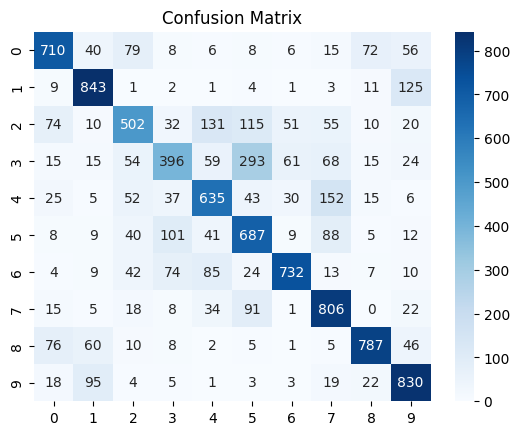

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [36]:
cnn_model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
print("Training CNN...")
train(cnn_model, criterion, optimizer, train_loader, test_loader, epochs=10, patience=5)
evaluate(cnn_model, test_loader)

# Train & Evaluate ViT
vit_model = get_pretrained_vit().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vit_model.parameters(), lr=1e-4)

Training Pretrained ViT...
Epoch 1: Train Acc=98.64%, Val Acc=95.47%, Val Loss=0.1596
Epoch 2: Train Acc=98.91%, Val Acc=94.75%, Val Loss=0.1854
Epoch 3: Train Acc=98.76%, Val Acc=95.26%, Val Loss=0.1737
Epoch 4: Train Acc=98.91%, Val Acc=95.76%, Val Loss=0.1528
Epoch 5: Train Acc=99.22%, Val Acc=95.44%, Val Loss=0.1726
Epoch 6: Train Acc=99.80%, Val Acc=96.40%, Val Loss=0.1416
Epoch 7: Train Acc=99.97%, Val Acc=97.09%, Val Loss=0.1250
Epoch 8: Train Acc=100.00%, Val Acc=97.20%, Val Loss=0.1293
Epoch 9: Train Acc=100.00%, Val Acc=97.29%, Val Loss=0.1295
Epoch 10: Train Acc=100.00%, Val Acc=97.33%, Val Loss=0.1314
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1000
           1       0.98      0.99      0.98      1000
           2       0.99      0.97      0.98      1000
           3       0.93      0.94      0.93      1000
           4       0.97      0.98      0.98      1000
           5       0.95      0.94      0.94      1000


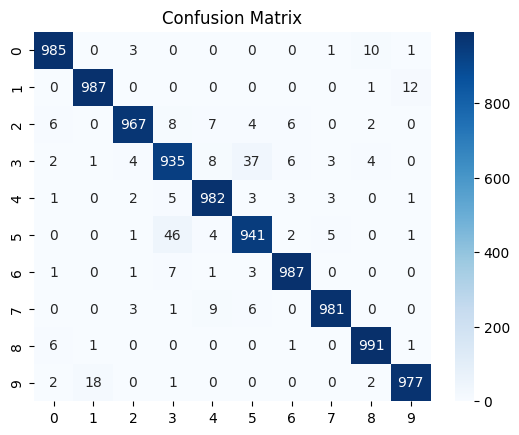

In [39]:
def resize_dataset(dataset):
    dataset.transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

resize_dataset(train_dataset)
resize_dataset(test_dataset)
train_loader_vit = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader_vit = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Training Pretrained ViT...")
train(vit_model, criterion, optimizer, train_loader_vit, test_loader_vit, epochs=10, patience=5)
evaluate(vit_model, test_loader_vit)
